# Network Traffic Analysis and Resource Allocation

## Objective
To analyze traffic patterns and optimize bandwidth allocation using data analytics and machine learning.

IMPORTS

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

SAMPLE DATASET(BASIC SIMULATION)

In [94]:
data = {
    "Slice": ["eMBB", "URLLC", "mMTC"],
    "Traffic_Demand": [80, 40, 60],
    "Latency_Requirement": [50, 10, 100]
}

df = pd.DataFrame(data)

total_bandwidth = 100

# Round Robin
df["RR_Allocation"] = total_bandwidth / len(df)

# Proposed Allocation
df["Proposed_Allocation"] = df["Traffic_Demand"] / df["Traffic_Demand"].sum() * total_bandwidth

# Weighted Allocation
df["Weight"] = df["Slice"].map({"eMBB":1, "URLLC":2, "mMTC":1})

df["Weighted_Allocation"] = (
    df["Traffic_Demand"] * df["Weight"]
) / (df["Traffic_Demand"] * df["Weight"]).sum() * total_bandwidth

df

# Lower allocation → higher latency
df["Latency_RR"] = df["Latency_Requirement"] * (df["Traffic_Demand"] / df["RR_Allocation"])
df["Latency_Proposed"] = df["Latency_Requirement"] * (df["Traffic_Demand"] / df["Weighted_Allocation"])

df

,Slice,Traffic_Demand,Latency_Requirement,RR_Allocation,Proposed_Allocation,Weight,Weighted_Allocation,Latency_RR,Latency_Proposed
0,eMBB,80,50,33.333333,44.444444,1,36.363636,120.0,110.0
1,URLLC,40,10,33.333333,22.222222,2,36.363636,12.0,11.0
2,mMTC,60,100,33.333333,33.333333,1,27.272727,180.0,220.0


Weighted allocation prioritizes URLLC and improves performance compared to round robin.

VISUALIZATION

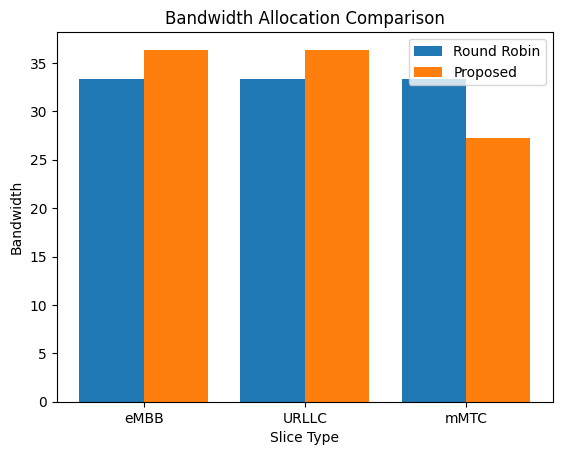

In [96]:
x = np.arange(len(df["Slice"]))

plt.figure()
plt.bar(x - 0.2, df["RR_Allocation"], width=0.4, label="Round Robin")
plt.bar(x + 0.2, df["Weighted_Allocation"], width=0.4, label="Proposed")

plt.xticks(x, df["Slice"])
plt.title("Bandwidth Allocation Comparison")
plt.xlabel("Slice Type")
plt.ylabel("Bandwidth")
plt.legend()
plt.show()

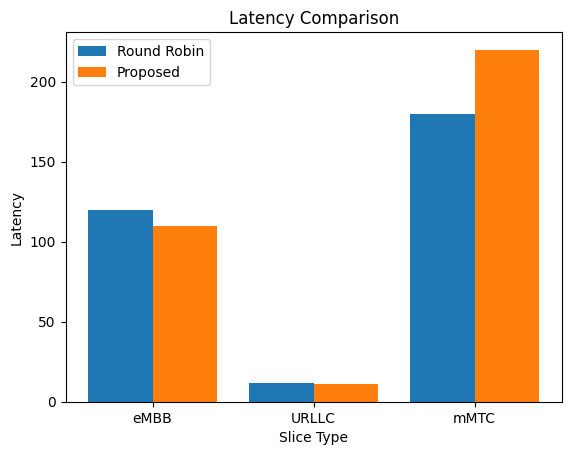

In [97]:
plt.figure()
plt.bar(x - 0.2, df["Latency_RR"], width=0.4, label="Round Robin")
plt.bar(x + 0.2, df["Latency_Proposed"], width=0.4, label="Proposed")

plt.xticks(x, df["Slice"])
plt.title("Latency Comparison")
plt.xlabel("Slice Type")
plt.ylabel("Latency")
plt.legend()
plt.show()

FAIRNESS
-Round Robin ensures fairness, but weighted allocation balances fairness with performance.

In [100]:
def fairness_index(allocation):
    return (allocation.sum() ** 2) / (len(allocation) * (allocation ** 2).sum())

rr_fairness = fairness_index(df["RR_Allocation"])
proposed_fairness = fairness_index(df["Weighted_Allocation"])

print("Round Robin Fairness:", rr_fairness)
print("Proposed Fairness:", proposed_fairness)

Round Robin Fairness: 0.9999999999999998
Proposed Fairness: 0.9837398373983739


In [101]:
comparison = df[["Slice", "RR_Allocation", "Weighted_Allocation", "Latency_RR", "Latency_Proposed"]]
comparison

,Slice,RR_Allocation,Weighted_Allocation,Latency_RR,Latency_Proposed
0,eMBB,33.333333,36.363636,120.0,110.0
1,URLLC,33.333333,36.363636,12.0,11.0
2,mMTC,33.333333,27.272727,180.0,220.0


LOAD REAL DATA

In [102]:
import pandas as pd

df = pd.read_csv("traffic_data.csv")

In [103]:
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   year        144 non-null    int64 
 1   month       144 non-null    object
 2   passengers  144 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 3.5+ KB


year          0
month         0
passengers    0
dtype: int64

DATA CLEANING

In [104]:
df = df.dropna()

In [105]:
df.columns

Index(['year', 'month', 'passengers'], dtype='object')

In [107]:
df = df.rename(columns={"passengers": "Traffic_Demand"})

CREATE FEATURES(Slice + Allocation)

In [108]:
import numpy as np

slices = ["eMBB", "URLLC", "mMTC"]
df["Slice"] = np.random.choice(slices, size=len(df))

In [109]:
df.groupby("Slice")["Traffic_Demand"].mean()

Slice
URLLC    295.820000
eMBB     255.157895
mMTC     283.500000
Name: Traffic_Demand, dtype: float64

In [110]:
df.columns = df.columns.str.strip()

EXPLORATORY DATA ANALYSIS (EDA)

TRAFFIC DISTRIBUTION-
Traffic demand varies across the dataset, indicating uneven usage patterns in the network.

Text(0.5, 1.0, 'Traffic Distribution')

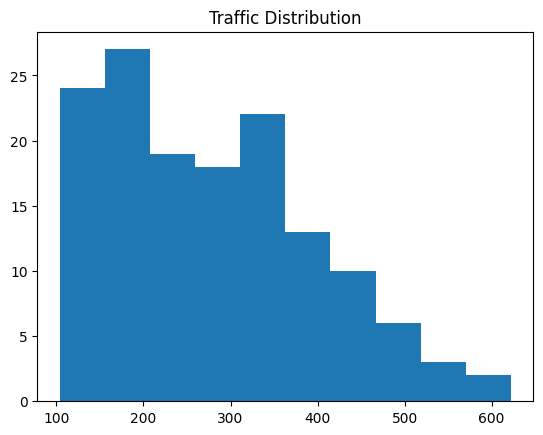

In [111]:
plt.hist(df["Traffic_Demand"])
plt.title("Traffic Distribution")

TRAFFIC TREND
-Traffic fluctuates over time, showing dynamic behavior and the need for adaptive allocation.

Text(0.5, 1.0, 'Traffic Trend Over Time')

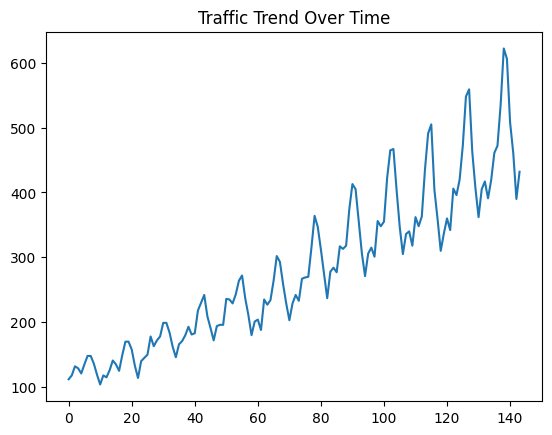

In [112]:
plt.plot(df["Traffic_Demand"])
plt.title("Traffic Trend Over Time")

In [113]:
df["Load_Ratio"] = df["Traffic_Demand"] / df["Traffic_Demand"].max()
df["High_Traffic"] = df["Traffic_Demand"] > df["Traffic_Demand"].mean()

SLICE-WISE COMPARISION-eMBB shows higher traffic demand compared to other slices, indicating high bandwidth usage.

<Axes: xlabel='Slice'>

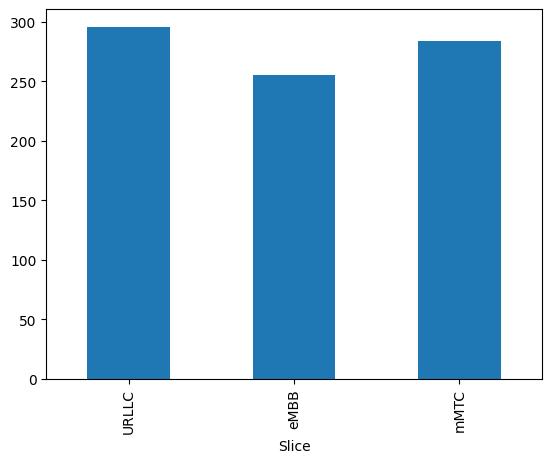

In [114]:
df.groupby("Slice")["Traffic_Demand"].mean().plot(kind='bar')

{'whiskers': [<matplotlib.lines.Line2D at 0x23cf5741550>,
 'caps': [<matplotlib.lines.Line2D at 0x23cf5741940>,
 'boxes': [<matplotlib.lines.Line2D at 0x23cf5741340>],
 'medians': [<matplotlib.lines.Line2D at 0x23cf5741eb0>],
 'fliers': [<matplotlib.lines.Line2D at 0x23cf5742120>],
 'means': []}

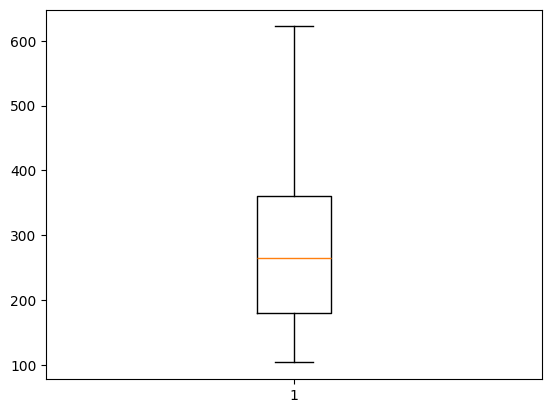

In [115]:
plt.boxplot(df["Traffic_Demand"])

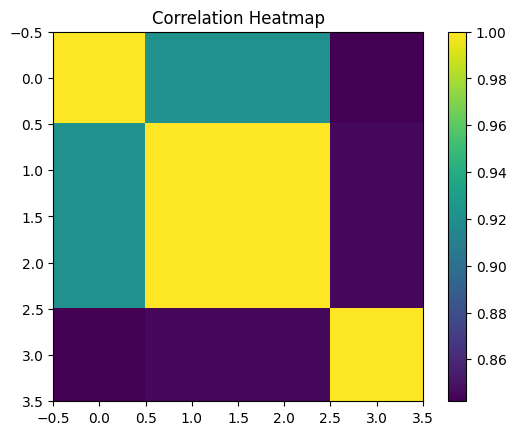

In [116]:
df.corr(numeric_only=True)
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Heatmap")
plt.show()

In [117]:
df["Weight"] = df["Slice"].map({
    "eMBB": 1,
    "URLLC": 2,   # higher priority
    "mMTC": 1
})
total_bandwidth = 100

df["Allocated_Bandwidth"] = (df["Traffic_Demand"] * df["Weight"]) / (df["Traffic_Demand"] * df["Weight"]).sum() * total_bandwidth

MACHINE LEARNING MODEL
The model predicts allocation based on traffic demand, enabling data-driven decision making.

In [118]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X = df[["Traffic_Demand"]]
y = df["Allocated_Bandwidth"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = DecisionTreeRegressor()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, pred))

MSE: 0.11202853023705528


In [119]:
df["Utilization"] = df["Allocated_Bandwidth"] / 100
df["Efficiency"] = df["Allocated_Bandwidth"] / df["Traffic_Demand"]

In [120]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


CONCLUSION
This project demonstrates how data analysis and machine learning can be used to understand traffic patterns and optimize resource allocation effectively.